# Abschlussbericht: Erweiterung des A*

In diesem Abschlussbericht werden die in der Aufgabenstellung geforderten Strategien behandelt, insbesondere:

- *Diskretisierung des A*-Algorithmus
- *Umgang mit Start- und Zielwerten, die nicht auf dem A*-Gitter liegen
- *Kantenkollisionserkennung*
- *Reopening-Strategie*
- *Die Ergebnisse*

Damit werden die Aufgaben 1 und 2 umfassend abgedeckt.

### Aufgabe I.1.a. Eine veränderliche Diskretisierung

In der Standardimplementierung verwendet der A*-Algorithmus üblicherweise eine feste Schrittweite von 1, unabhängig von der Skalierung der Umgebung. Das Ziel dieser Erweiterung ist es, jede Achse des Konfigurationsraums in eine definierbare Anzahl von Schritten unterteilen zu können (variable Diskretisierung).

Unsere Strategie basiert darauf, die Grenzen der Umgebung (limits) durch die gewünschte Anzahl an Schritten (num_steps) zu teilen. Die Berechnung erfolgt gemäß den folgenden Formeln:

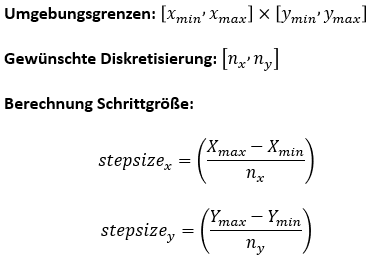

Daraus resultiert ein Gitter, bei dem die Eckpunkte der Zellen den Knotenpunkten für die A*-Suche entsprechen. Dieses Prinzip wird hier am Beispiel eines 2D-Raums demonstriert, lässt sich jedoch analog auf höherdimensionale Räume übertragen.

Ein Problem stellen Start- und Zielpunkte dar, deren Koordinaten keine Vielfachen der berechneten Schrittweite sind. Diese Punkte liegen nicht exakt auf dem Gitter ("Off-Grid") und sind somit für den Algorithmus zunächst nicht "erreichbar". In diesem Fall wird der nächstgelegene Punkt auf dem Gitter ermittelt. Dies geschieht mithilfe der folgenden Formel:

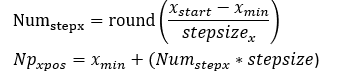

Hierbei steht x_start für die reale Koordinate und N_pxpos für die Koordinate des nächstgelegenen Gitterpunktes. Dieses Verfahren wird für alle Achsen sowie analog für den Zielpunkt angewendet.
Die eigentliche Pfadsuche findet anschließend zwischen diesen diskreten Gitterpunkten statt. Ein Nachteil dieser "Nearest-Neighbor"-Methode ist jedoch, dass der Pfad durch die Wahl des nächstgelegenen Punktes unter Umständen verlängert werden kann, wie im folgenden Beispiel illustriert wird:

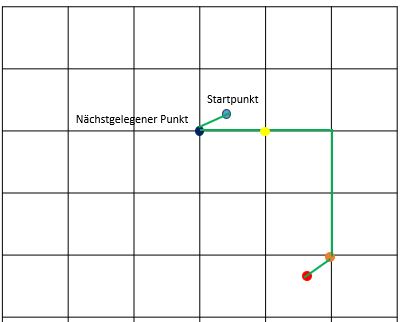

In diesem Beispiel ist der dunkelblaue Punkt zwar der geometrisch nächstgelegene zum Startpunkt, jedoch würde der Start über den gelben Punkt zu einem insgesamt kürzeren Pfad führen. Sofern die Schrittweite hinreichend klein und der Gesamtpfad lang genug ist, kann diese Abweichung jedoch vernachlässigt werden.

Bei größeren Schrittweiten besteht zudem das Risiko, dass sich ein Hindernis zwischen der realen Start-/Zielposition und dem zugehörigen Gitterpunkt befindet. Daher wird vor Beginn der Suche eine Kollisionsprüfung zwischen diesen beiden Punkten durchgeführt. Im Falle einer Kollision wird der Vorgang abgebrochen und eine Anpassung der Start- oder Zielposition gefordert (eine alternative Lösung wäre hier die Wahl des zweitnächsten Gitterpunktes gewesen).

Ist die Verbindung kollisionsfrei, wird die Pfadsuche gestartet. Nach erfolgreicher Berechnung werden die realen Start- und Ziel schließlich dem Graphen und dem resultierenden Pfad hinzugefügt.

### Aufgabe I.1.b Kantenkollision


Während bei der Knotenkollision nur geprüft wird, ob ein einzelner Punkt frei ist, betrachtet die Kantenkollision auch den Weg zwischen zwei Punkten. Ohne diese Prüfung könnten Hindernisse übersehen werden, die zwischen Start- und Zielpunkt liegen.

##### Unsere Vorgehensweise bei der Kantenkollisionsprüfung

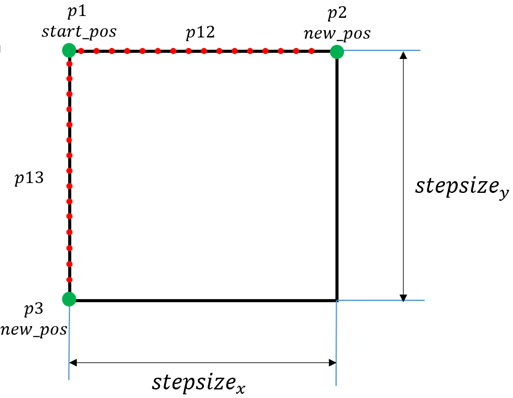

- Jede Kante wird in *k* gleichmäßig verteilte Zwischenpunkte unterteilt. In der nachfolgenden Skizze kleine Rote punkte.  
- Jeder dieser Punkte wird mit der Funktion `PointInCollision()` auf Kollision geprüft.  
- Nur wenn alle Zwischenpunkte kollisionsfrei sind, gilt die gesamte Kante als gültig.  

Ist dies der Fall, wird der entsprechende Nachbarpunkt in die OpenList aufgenommen (z.B. \[p12, p13, ...\]).

Tritt bei einem der Zwischenpunkte eine Kollision auf, wird die Kante verworfen und der Nachbar nicht weiter berücksichtigt.

**Hinweis:** Unserer Erfahrung nach ist die Kantenkollisionsprüfung insbesondere bei groben Diskretisierungen wichtig, da sonst kleine Hindernisse zwischen den Knoten und entlang der Kanten übersehen werden können.



---
### Aufgabe II) 

Mit welchen Bewegungsbefehlen würden Sie den Ergebnispfad des A* in ein Roboterprogramm umwandeln. Erläutern Sie, warum das zwar möglich ist, aber es nicht unbedingt sinnvoll ist.
Was müssen Sie machen, damit er sinnvoll abgefahren werden kann. Erläutern Sie die Vorgehensweise.


Der A*-Algorithmus liefert einen geometrischen Pfad als Folge diskreter Punkte. Bewegungsbefehle wie `Move_Forward()`, `Turn_Left()` und `Turn_Right()` können den Roboter entlang dieses Pfads steuern.  

**Warum das nicht sinnvoll ist:**  
- Bei hoher Dimensionalität (z.B. 3 Achsen mit je 20 Schritten → 20³=8.000 Punkte, bei 6 Achsen sogar 20⁶ = 64 Mio. Punkte) wächst der Suchraum exponentiell, was die Rechenzeit drastisch erhöht.
- A* ignoriert fahrzeugspezifische Einschränkungen (z.B. Wendekreis, Trägheit).  
- Der Pfad führt zu abrupten, ruckartigen Bewegungen, die für den Roboter belastend sind.  


**Wie man den Pfad sinnvoll nutzbar macht:**  
- Pfad nachbearbeiten und glätten, um sanfte Kurven statt scharfer Winkel zu erhalten.  
- Realistische Bewegungsprofile berücksichtigen (Lenkwinkel, Geschwindigkeit).  
- Steuerbefehle nutzen, die stufenlos Lenkung und Geschwindigkeit regeln, statt nur simple Richtungswechsel.

So kann der Roboter den Pfad flüssig und realistisch abfahren.


### Aufgabe I.2. Reopening

#### A* ohne Reopening

In der bisherigen Implementierung des A*-Algorithmus wird immer ein Knoten expandiert. Dabei handelt es sich um den Knoten mit den geringsten Kosten bzw. den Startknoten.
Wird bei der Expansion eines Knotens ein Knoten besucht, der bereits im Graph vorhanden ist, wird dieser Knoten übersprungen und die Kosten können nicht aktualisiert werden.

**Beispiel ohne Reopening:**

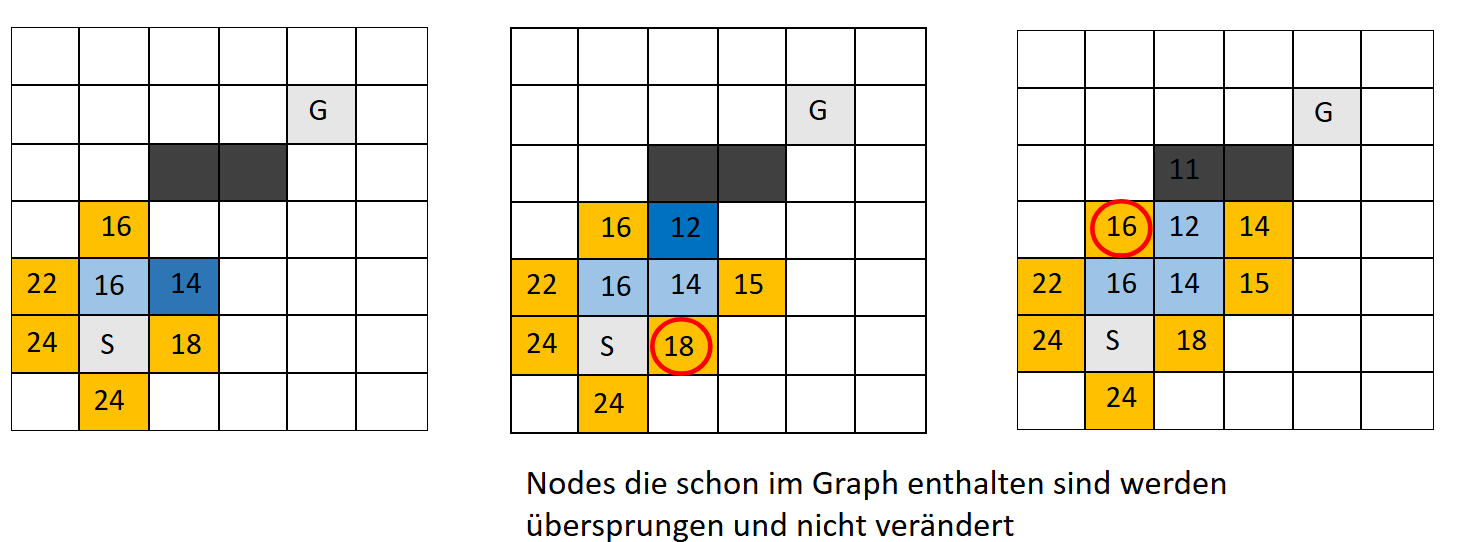

**Hinweis:** Die Zahlen in den Knoten stellen die Gesamtkosten f(n) dar, die sich aus den tatsächlichen Kosten g(n) und den heuristischen Kosten h(n) zusammensetzen. Die Zahlen wurden hier ohne Bedeutung gewählt und dienen nur der Veranschaulichung. Die Sinnhaftigkeit der Werte ist in diesem Beispiel nicht relevant. Es soll lediglich die Funktionsweise ohne Reopening verdeutlicht werden.

#### A* mit Reopening
Bei der neuen Implementierung mit Reopening wird bei der Expansion eines Knotens überprüft, ob der Knoten bereits im Graph vorhanden ist. Ist dies nicht der Fall, wird der Knoten wie gewohnt hinzugefügt.

Ist der Knoten jedoch bereits im Graphen vorhanden, werden die Kosten des Knotens mit den neuen Kosten verglichen. Im Speziellen wird hier g(n) betrachtet, also die Kosten vom Startknoten bis zum aktuellen Knoten n. die heuristischen Kosten h(n) bleiben unverändert, da diese nur von der Position des Knotens abhängen.

Sollten die neuen Kosten g(n) geringer sein als die bisherigen Kosten, werden sie aktualisiert und der Knoten wird erneut in die OpenList aufgenommen, um neu evaluiert zu werden. Es werden ebenfalls die Elternknoten aktualisiert, um den neuen Pfad widerzuspiegeln. Dazu werden die alten Verbindungen entfernt und die neuen Verbindungen hinzugefügt.

wird bei der Überprüfung festgestellt, dass die neuen Kosten g(n) höher oder gleich sind wie die bisherigen Kosten, wird der Knoten ignoriert und die Expansion wird fortgesetzt.

**Beispiel mit Reopening:**

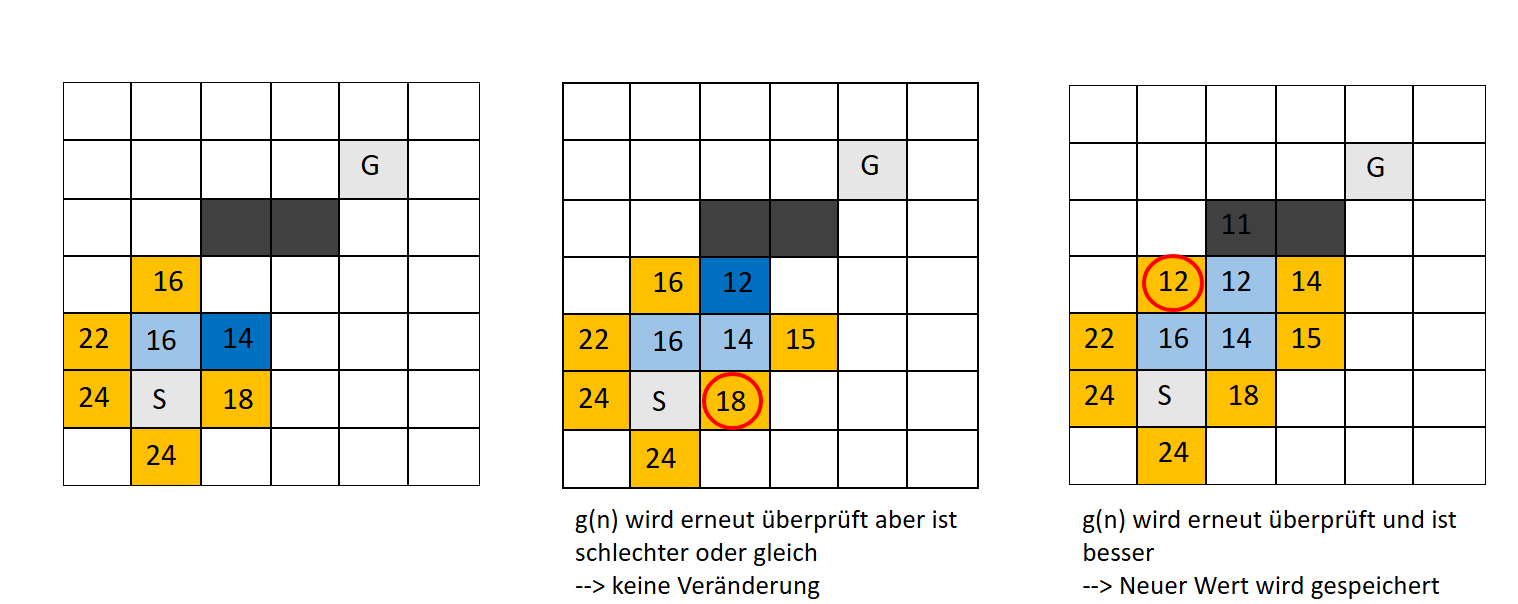

**Hinweis:** Die Zahlen in den Knoten stellen die Gesamtkosten f(n) dar, die sich aus den tatsächlichen Kosten g(n) und den heuristischen Kosten h(n) zusammensetzen. Die Zahlen wurden hier ohne Bedeutung gewählt und dienen nur der Veranschaulichung. Die Sinnhaftigkeit der Werte ist in diesem Beispiel nicht relevant. Es soll lediglich die Funktionsweise des Reopenings verdeutlicht werden.

#### Einfluss des Gewichtsfaktors w
Der Gewichtungsfaktor w bestimmt wie stark die heuristischen Kosten h(n) im Vergleich zu den tatsächlichen Kosten g(n) in die Gesamtkosten f(n) einfließen:

**f(n) = w * h(n) + (1-w) * g(n)**

Mit zunehmendem w wird die Suche stärker auf die heuristischen Kosten fokussiert, was zu schnelleren, aber möglicherweise suboptimalen Pfaden führt. In diesem Zusammenhang gewinnt die Reopening-Strategie an Bedeutung, da sie erlaubt Fehlentcheidungen zu korrigieren,und somit die Pfadqualität zu verbessern.

Bei kleinem w hingegen bringt die Reopening-Strategie weniger Vorteile, da hier die Knoten schon bei der ersten Expansion mit hoher Wahrscheinlichkeit optimal bewertet werden.

#### Vor- und Nachteile des Reopening-Ansatzes

Durch den Einsatz von Reopening werden die vom A*-Algorithmus berechneten Pfade qualitativ hochwertiger und zuverlässiger, da bereits geschlossene Knoten erneut berücksichtigt werden können, wenn ein kostengünstigerer Zugang zu ihnen gefunden wird. Dadurch lassen sich suboptimale Entscheidungen, die durch ungenaue oder inkonsistente Heuristiken entstehen, nachträglich korrigieren. Dies ist insbesondere in komplexen oder dynamischen Umgebungen von Vorteil. Reopening trägt somit wesentlich zur Annäherung an optimale Lösungen bei und erhöht die Robustheit des Planungsverfahrens. Demgegenüber stehen jedoch ein erhöhter Rechenaufwand und ein gesteigerter Speicherbedarf, da die Knoten mehrfach verarbeitet und ihre Kostenwerte aktualisiert werden müssen.
Reopening stellt somit einen klassischen Zielkonflikt zwischen Lösungsqualität und algorithmischer Effizienz dar.



### Aufgabe I.3 Die Ergennisse 

* a. Punkt-Roboter : 
* b. Shape-Roboter : Schauen Sie IP-X-1-Automated_PlanerTest_Shape-Roboter_3-DoF
* c. PlanarManipulator : Schauen Sie IP-X-1-Automated_PlanerTest_PlanarManipulator_3-DoF_Presentation

---
### Aufgabe II) 

Mit welchen Bewegungsbefehlen würden Sie den Ergebnispfad des A* in ein Roboterprogramm umwandeln. Erläutern Sie, warum das zwar möglich ist, aber es nicht unbedingt sinnvoll ist.
Was müssen Sie machen, damit er sinnvoll abgefahren werden kann. Erläutern Sie die Vorgehensweise.


Der A*-Algorithmus liefert einen geometrischen Pfad als Folge diskreter Punkte. Bewegungsbefehle wie `Move_Forward()`, `Turn_Left()` und `Turn_Right()` können den Roboter entlang dieses Pfads steuern.  

**Warum das nicht sinnvoll ist:**  
- Bei hoher Dimensionalität (z.B. 3 Achsen mit je 20 Schritten → 20³=8.000 Punkte, bei 6 Achsen sogar 20⁶ = 64 Mio. Punkte) wächst der Suchraum exponentiell, was die Rechenzeit drastisch erhöht.
- A* ignoriert fahrzeugspezifische Einschränkungen (z.B. Wendekreis, Trägheit).  
- Der Pfad führt zu abrupten, ruckartigen Bewegungen, die für den Roboter belastend sind.  


**Wie man den Pfad sinnvoll nutzbar macht:**  
- Pfad nachbearbeiten und glätten, um sanfte Kurven statt scharfer Winkel zu erhalten.  
- Realistische Bewegungsprofile berücksichtigen (Lenkwinkel, Geschwindigkeit).  
- Steuerbefehle nutzen, die stufenlos Lenkung und Geschwindigkeit regeln, statt nur simple Richtungswechsel.

So kann der Roboter den Pfad flüssig und realistisch abfahren.
